# BrushCue Example: Median Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/median_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/median-filter

In [ ]:
!pip install brushcue

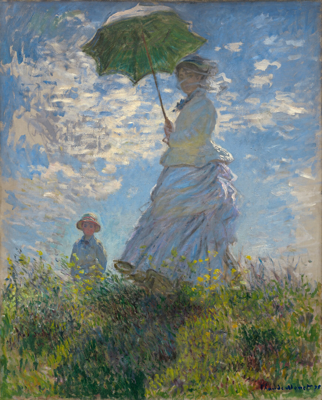

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let kernel_width = kernel_size * 2 - 1;\nlet kernel_area = kernel_width * kernel_width;\n\nvar r_samples = array<f32, 81>();\nvar g_samples = array<f32, 81>();\nvar b_samples = array<f32, 81>();\nvar sample_count = 0;\n\nfor (var dy = -kernel_size + 1; dy < kernel_size; dy = dy + 1) {\n  for (var dx = -kernel_size + 1; dx < kernel_size; dx = dx + 1) {\n    let offset_pos = vec2<i32>(position) + vec2<i32>(dx, dy);\n    let pixel = textureLoad(input_texture, offset_pos, 0);\n    r_samples[sample_count] = pixel.r;\n    g_samples[sample_count] = pixel.g;\n    b_samples[sample_count] = pixel.b;\n    sample_count = sample_count + 1;\n  }\n}\n\nfor (var i = 0; i < sample_count - 1; i = i + 1) {\n  for (var j = i + 1; j < sample_count; j = j + 1) {\n    if (r_samples[j] < r_samples[i]) {\n      let temp = r_samples[i];\n      r_samples[i] = r_samples[j];\n      r_samples[j] = temp;\n    }\n  }\n}\n\nfor (var i = 0; i < sample_count - 1; i = i + 1) {\n  for (var j = i + 1; j < sample_count; j = j + 1) {\n    if (g_samples[j] < g_samples[i]) {\n      let temp = g_samples[i];\n      g_samples[i] = g_samples[j];\n      g_samples[j] = temp;\n    }\n  }\n}\n\nfor (var i = 0; i < sample_count - 1; i = i + 1) {\n  for (var j = i + 1; j < sample_count; j = j + 1) {\n    if (b_samples[j] < b_samples[i]) {\n      let temp = b_samples[i];\n      b_samples[i] = b_samples[j];\n      b_samples[j] = temp;\n    }\n  }\n}\n\nlet median_index = sample_count / 2;\nlet median_r = r_samples[median_index];\nlet median_g = g_samples[median_index];\nlet median_b = b_samples[median_index];\nlet median_a = input.a;\n\nreturn vec4<f32>(median_r, median_g, median_b, median_a);")
string_constant_3 = brushcue.string_constant("// No helpers needed for this.")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
dictionary_create_6 = brushcue.dictionary_create()
string_constant_7 = brushcue.string_constant("kernel_size")
int_constant_8 = brushcue.int_constant(2)
kernel_size_9 = brushcue.int_passthrough(int_constant_8)
int_add_to_dictionary_10 = brushcue.int_add_to_dictionary(dictionary_create_6, string_constant_7, kernel_size_9)
composition_custom_transformer_shader_11 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_4, int_add_to_dictionary_10, bool_constant_5)

ctx = brushcue.Context()
result = composition_custom_transformer_shader_11.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
